In [1]:
import cv2
from cv2 import aruco
import numpy as np
import msgpack as mp
import msgpack_numpy as mpn
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

In [2]:
useDeng = False
cameraNumber = 4
useFisheye = True

patternSize = (6, 4)
squareSize = 40
imgSize = (1280, 800)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

def construct3DPoints(patternSize, squareSize):
    X = np.zeros((patternSize[0] * patternSize[1], 3), np.float32)
    X[:, :2] = np.mgrid[0 : patternSize[0], 0 : patternSize[1]].T.reshape(-1, 2)
    X = X * squareSize
    return X


boardPoints = construct3DPoints(patternSize, squareSize)

In [3]:
_pth = os.path.dirname(os.getcwd())
_parent_folder = "data"
_calib_folder_name = "calib_mono_160_better_view_2026"

_webcam_calib_folder = os.path.join(
    _pth,'..', _parent_folder, "calibration",'160_fov', _calib_folder_name
)
_webcam_calib_video = os.path.join(_webcam_calib_folder, "webcam_color.msgpack")
_webcam_calib_folder = os.path.join(_webcam_calib_folder)
_webcam_calib_pth = os.path.join(_webcam_calib_folder, "webcam_calibration.msgpack")

In [4]:
_video_pth = _webcam_calib_video
_video_file = open(_video_pth, "rb")
_video_data = mp.Unpacker(_video_file, object_hook=mpn.decode)
_video_length = 0

for _frame in _video_data:
    _video_length += 1

_video_file.close()

print('video length, ', _video_length)

video length,  6790


In [5]:
_video_pth = _webcam_calib_video
_video_file = open(_video_pth, "rb")
_video_data = mp.Unpacker(_video_file, object_hook=mpn.decode)

chessb_corners = []
counter = 0

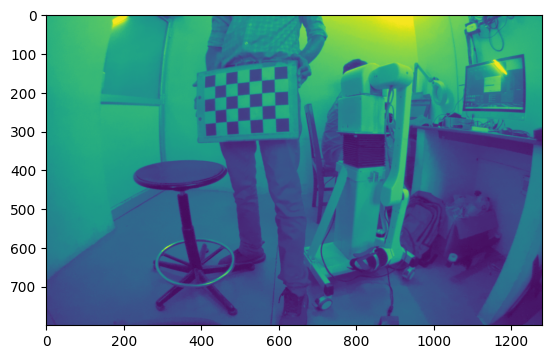

In [ ]:
plt.imshow(_frame)

In [ ]:
# for idx, frame in enumerate(tqdm(_video_data)):
def detectCorners(_frame):
    # _frame = cv2.rotate(_frame.copy(), cv2.ROTATE_180)

    ret, corners = cv2.findChessboardCorners(_frame, patternSize)
    if ret:
        corners = cv2.cornerSubPix(
            _frame,
            corners,
            (5, 5),
            (-1, -1),
            criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001),
        )
    return corners
# Parallel execution with joblib
chessb_corners = []
results = Parallel(n_jobs=20, verbose=0)(
    delayed(detectCorners)(frame) for frame in tqdm(_video_data)
)


0it [00:00, ?it/s]

# Clean up the inhomogeneous  part

In [ ]:
# Collect results
chessb_corners = []
for result in results:
    if result is not None and len(result) == 24:
        chessb_corners.append(result)

In [ ]:
# Get the directory of the video file
video_dir = os.path.dirname(_video_pth)
corners_file = os.path.join(video_dir, "chessb_corners.msgpack")

with open(corners_file, "wb") as f:
    _packed_file = mp.packb(chessb_corners, default=mpn.encode)
    f.write(_packed_file)

# del(chessb_corners)

In [ ]:
STOP_HERE

NameError: name 'STOP_HERE' is not defined

# Creating combinations

In [1]:
import cv2
from cv2 import aruco
import numpy as np
import msgpack as mp
import msgpack_numpy as mpn
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
# np.random.seed(9)

In [2]:
_pth = os.path.dirname(os.getcwd())
_parent_folder = "data"
_calib_folder_name = "calib_mono_160_better_view_2026"

_webcam_calib_folder = os.path.join(
    _pth,'..', _parent_folder, "calibration",'160_fov', _calib_folder_name
)

_webcam_calib_video = os.path.join(_webcam_calib_folder, "webcam_color.msgpack")
_webcam_calib_folder = os.path.join(_webcam_calib_folder)
_webcam_corners_pth = os.path.join(_webcam_calib_folder, "chessb_corners.msgpack")

In [3]:
# load data

_corners_file = open(_webcam_corners_pth, "rb")
chessb_corners = list(mp.Unpacker(_corners_file, object_hook=mpn.decode))
chessb_corners = chessb_corners[0]
chessb_corners = np.array(chessb_corners)

In [4]:
useDeng = False
cameraNumber = 4
useFisheye = True

patternSize = (6, 4)
squareSize = 40
imgSize = (1280, 800)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)


def construct3DPoints(patternSize, squareSize):
    X = np.zeros((patternSize[0] * patternSize[1], 3), np.float32)
    X[:, :2] = np.mgrid[0 : patternSize[0], 0 : patternSize[1]].T.reshape(-1, 2)
    X = X * squareSize
    return X


boardPoints = construct3DPoints(patternSize, squareSize)

In [5]:
permute_value = 200


In [6]:


def calibrate_single_iteration(_):
    rnd = np.random.choice(len(chessb_corners), 80)
    chessb_c = chessb_corners[rnd]
    worldPoints = []
    imagePoints = []

    for _f in chessb_c:
        imagePoints.append(_f)
        worldPoints.append(boardPoints)

    if useFisheye:
        flagsCalib = (
            cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC
            + cv2.fisheye.CALIB_FIX_SKEW
            + cv2.fisheye.CALIB_CHECK_COND
        )
        calibrateCriteria = (
            cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
            30,
            1e-12,
        )
        ret, cameraMatrix, k, R, t = cv2.fisheye.calibrate(
            np.expand_dims(np.asarray(worldPoints), -2),
            imagePoints,
            imgSize,
            None,
            None,
            flags=flagsCalib,
            criteria=calibrateCriteria,
        )
    else:
        flagsCalib = cv2.CALIB_RATIONAL_MODEL
        ret, cameraMatrix, k, R, t = cv2.calibrateCamera(
            worldPoints, imagePoints, imgSize, None, None, flags=flagsCalib
        )

    # print(worldPoints)
    return {"ReError": ret, "mat": cameraMatrix, "dist": k, "rvec": R, "tvec": t, 'rnd':rnd}


# Parallel execution with joblib
my_dict = {"ReError": [], "mat": [], "dist": [], "rvec": [], "tvec": [], 'rnd_value':[]}


results = Parallel(n_jobs=20, verbose=0)(
    delayed(calibrate_single_iteration)(_) for _ in tqdm(range(permute_value))
)
# Collect results
for result in results:
    my_dict["ReError"].append(result["ReError"])
    my_dict["mat"].append(result["mat"])
    my_dict["dist"].append(result["dist"])
    my_dict["rvec"].append(result["rvec"])
    my_dict["tvec"].append(result["tvec"])
    my_dict['rnd_value'].append(result['rnd'])


# calibrate_single_iteration(10)

  0%|          | 0/200 [00:00<?, ?it/s]

In [7]:
# video_dir = os.path.dirname(_video_pth)
calibration_file = os.path.join(_webcam_calib_folder, f"calibration_data_{permute_value}.msgpack")

with open(calibration_file, "wb") as f:
    _packed_file = mp.packb(my_dict, default=mpn.encode)
    f.write(_packed_file)

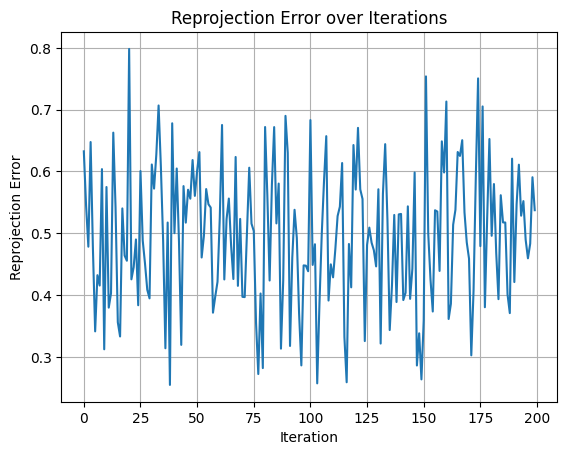

In [8]:
plt.plot(my_dict['ReError'])
plt.xlabel('Iteration')
plt.ylabel('Reprojection Error')
plt.title('Reprojection Error over Iterations')
plt.grid()

In [9]:
min_rerr_idx = np.argmin(my_dict['ReError'])
print('Minimum Reprojection Error:', my_dict['ReError'][min_rerr_idx], ' at index ', min_rerr_idx)

Minimum Reprojection Error: 0.25447990528791214  at index  38


In [10]:
rerr = my_dict['ReError'][min_rerr_idx]
camera_mat = my_dict['mat'][min_rerr_idx]
camera_dist = my_dict['dist'][min_rerr_idx]

In [11]:
print(rerr, camera_mat, camera_dist)

0.25447990528791214 [[591.04089767   0.         663.26435924]
 [  0.         594.37281395 368.20947424]
 [  0.           0.           1.        ]] [[-0.03476027]
 [-0.00305832]
 [-0.00043488]
 [-0.00018442]]


Translation Vector Standard Deviation: [260.56105187 138.44868414 133.49637925]


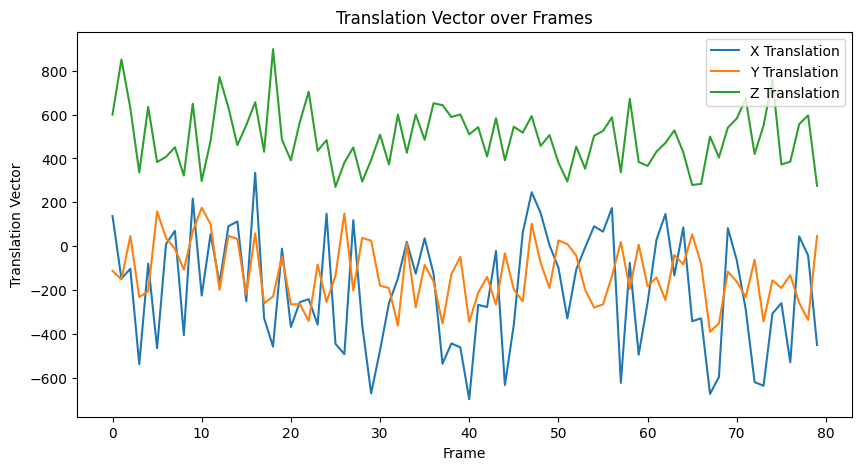

In [12]:
# plot the translation vector
tvec = my_dict['tvec'][0]
tvec = np.array(tvec).T[0]
plt.figure(figsize=(10, 5))
plt.plot(tvec[0], label='X Translation')
plt.plot(tvec[1], label='Y Translation')
plt.plot(tvec[2], label='Z Translation')
plt.xlabel('Frame')
plt.ylabel('Translation Vector')
plt.title('Translation Vector over Frames')
plt.legend()

# standard deviation of the translation vector
tvec_std = np.std(tvec, axis=1)
print('Translation Vector Standard Deviation:', tvec_std)

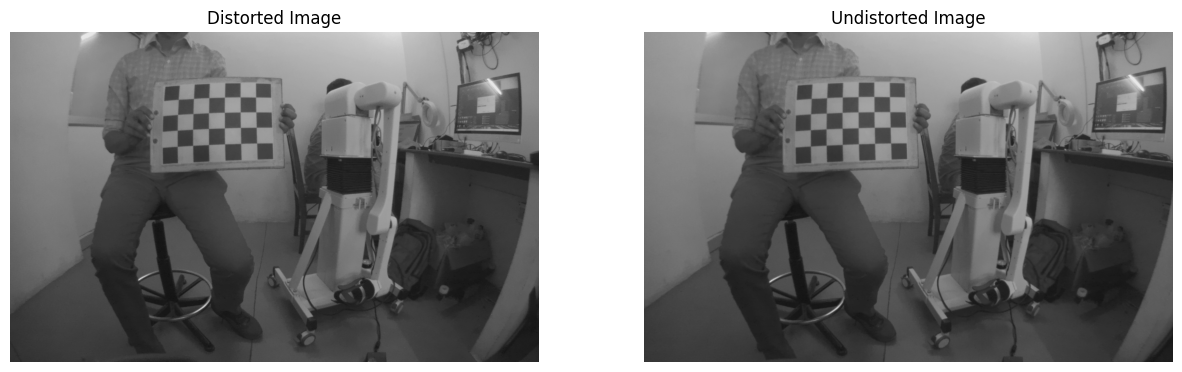

In [13]:
# show distorted and undistorted images
_video_pth = _webcam_calib_video
_video_file = open(_video_pth, "rb")
_video_data = mp.Unpacker(_video_file, object_hook=mpn.decode)
for idx, frame in enumerate(_video_data):
    # frame = cv2.flip(frame, 0)
    # frame = cv2.rotate(frame, cv2.ROTATE_180)
    frame_undistorted = cv2.undistort(frame, camera_mat, camera_dist)
    # create a subplot with 2 images and break at first image and plot chessboard corners
    
    if idx == 0:
        plt.figure(figsize=(15, 8))
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title('Distorted Image')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(frame_undistorted, cv2.COLOR_BGR2RGB))
        plt.title('Undistorted Image')
        plt.axis('off')
        plt.show()
        break

In [14]:
STOP_HERE

NameError: name 'STOP_HERE' is not defined

# Analysis by using a second video

In [1]:
import sys
import cv2
from cv2 import aruco
import numpy as np
import msgpack as mp
import msgpack_numpy as mpn
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import polars as pl
from datetime import datetime
    
sys.path.insert(1, os.path.dirname(os.getcwd()))
from pd_support import *
from scipy.spatial.transform import Rotation as R
import polars as pl
import os
from scipy.interpolate import interp1d
from joblib import Parallel, delayed

In [2]:
_pth = os.path.dirname(os.getcwd())
_parent_folder = "data"
_calib_folder_name = "calib_mono_160_better_view_2026"
_recording_folder_name = "3marker_linear_2d_160fov_t0"

_webcam_calib_folder = os.path.join(
    _pth,'..', _parent_folder, "calibration",'160_fov', _calib_folder_name
)

_reference_recording_folder = os.path.join(
    _pth, '..', _parent_folder, "recordings",'160_fov','3marker_complete_data', _recording_folder_name
)
_reference_file = os.path.join(_reference_recording_folder, "webcam_color.msgpack")

# for loading 9000 values
_calibration_data = os.path.join(_webcam_calib_folder, 'calibration_data_1000.msgpack')

# for loading just 100 points
_calibration_data = os.path.join(_webcam_calib_folder, 'calibration_data_100.msgpack')
_calibration_data = os.path.join(_webcam_calib_folder, 'calibration_data_2000.msgpack')
_calibration_data = os.path.join(_webcam_calib_folder, 'calibration_data_200.msgpack')

_timestamp_file = os.path.join(_reference_recording_folder, "webcam_timestamp.msgpack")
with open(_timestamp_file, "rb") as f:
    _metadata = list(mp.Unpacker(f, object_hook=mpn.decode))
    _timestamp = np.array(_metadata)[:,1]
    _sync_pulse = np.array(_metadata)[:,0]

### load calibration combinations

In [3]:
permute_value = 200

_calibration_data = os.path.join(_webcam_calib_folder, f'calibration_data_{permute_value}.msgpack')
with open(_calibration_data, 'rb') as f:
    my_dict = list(msgpack.Unpacker(f, object_hook=mpn.decode))
my_dict = my_dict[0]

In [4]:
_ref_video_length = 0

for _ in mp.Unpacker(open(_reference_file, "rb"), object_hook=mpn.decode):
    _ref_video_length += 1

print('video length, ', _ref_video_length)

video length,  4245


In [5]:
ARUCO_PARAMETERS = aruco.DetectorParameters()
ARUCO_DICT = aruco.getPredefinedDictionary(aruco.DICT_APRILTAG_36h11)
detector = aruco.ArucoDetector(ARUCO_DICT, ARUCO_PARAMETERS)
markerLength = 0.05
markerSeperation = 0.01

board = aruco.GridBoard(
    size=[1, 1],
    markerLength=markerLength,
    markerSeparation=markerSeperation,
    dictionary=ARUCO_DICT,
)

def estimate_pose_single_markers(
    corners, marker_size, camera_matrix, distortion_coefficients = np.zeros((5, 1))
):
    marker_points = np.array(
        [
            [-marker_size / 2, marker_size / 2, 0],
            [marker_size / 2, marker_size / 2, 0],
            [marker_size / 2, -marker_size / 2, 0],
            [-marker_size / 2, -marker_size / 2, 0],
        ],
        dtype=np.float32,
    )
    rvecs, tvecs = [], []
    for corner in corners:
        _, r, t = cv2.solvePnP(
            marker_points,
            corner,
            camera_matrix,
            distortion_coefficients,
            flags=cv2.SOLVEPNP_ITERATIVE,
        )
        if r is not None and t is not None:
            rvecs.append(r.reshape(1, 3).tolist())
            tvecs.append(t.reshape(1, 3).tolist())
        else:
            rvecs.append(np.array([[np.nan, np.nan, np.nan]]).tolist())
            tvecs.append(np.array([[np.nan, np.nan, np.nan]]).tolist())
    return np.array(rvecs, dtype=np.float32), np.array(tvecs, dtype=np.float32)

## load clalibration data

In [6]:
_calib_data = list(mp.Unpacker(open(_calibration_data, "rb"), object_hook=mpn.decode))

In [7]:
len(_calib_data[0]['ReError'])

200

In [8]:
# selecting random 50 frames
np.random.seed(9)
_random_reference_frames_idx = np.random.choice(_ref_video_length, 300)

_ref_data = mp.Unpacker(open(_reference_file, "rb"), object_hook=mpn.decode)

# _ref_frames = []

ar_total_results = {'calib_idx':[], 'ar_data':[]}
ar_results = {'corners': [], 'ids': [], 'rejected': []}
vector_std = {'v1std':[], 'v2std':[], 'v3std':[], 'sum':[], 
              'r1std':[], 'r2std':[], 'r3std':[], 'r_sum':[]}

for idx, _frame in tqdm(enumerate(_ref_data)):
    # if idx in _random_reference_frames_idx:

        # _frame = cv2.rotate(_frame, cv2.ROTATE_180)
    # _frame = cv2.flip(_frame, 1)
    res = detector.detectMarkers(_frame,)
    
    res = detector.refineDetectedMarkers(_frame, board, res[0], res[1], res[2])
    ar_results['corners'].append(res[0])
    ar_results['ids'].append(res[1])
    ar_results['rejected'].append(res[2])

0it [00:00, ?it/s]

## path definition

In [9]:
_timestamp

array(['2026-02-12 17:28:08.279459', '2026-02-12 17:28:08.287229',
       '2026-02-12 17:28:08.299496', ..., '2026-02-12 17:28:50.712616',
       '2026-02-12 17:28:50.723040', '2026-02-12 17:28:50.734391'],
      shape=(4245,), dtype='<U26')

In [10]:
ar_df = {"time": _timestamp, "sync": _sync_pulse}
ar_df = pl.from_dict(ar_df)
if type(ar_df["time"][0]) is not datetime:
    ar_df = ar_df.with_columns(pl.col("time").str.to_datetime())

In [11]:
mocap_df, st_time = read_rigid_body_csv(
    os.path.join(_reference_recording_folder, f"{_recording_folder_name}.csv")
)
mocap_df = add_datetime_col(mocap_df, st_time, "seconds")
mocap_df = pl.from_pandas(mocap_df)

e:\CMC\pyprojects\programs_rpi\NOARK_backbone\notebooks\pd_support.py:326: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  _rb_df = _rb_df.apply(pd.to_numeric, errors="ignore")


In [12]:
tr = get_rb_marker_name(1)
tl = get_rb_marker_name(4)
br = get_rb_marker_name(2)
bl = get_rb_marker_name(5)

tr = get_rb_marker_name(8)
tl = get_rb_marker_name(6)
br = get_rb_marker_name(2)
bl = get_rb_marker_name(5)


# tr = get_rb_marker_name(4)
# tl = get_rb_marker_name(2)
# br = get_rb_marker_name(3)
# bl = get_rb_marker_name(1)

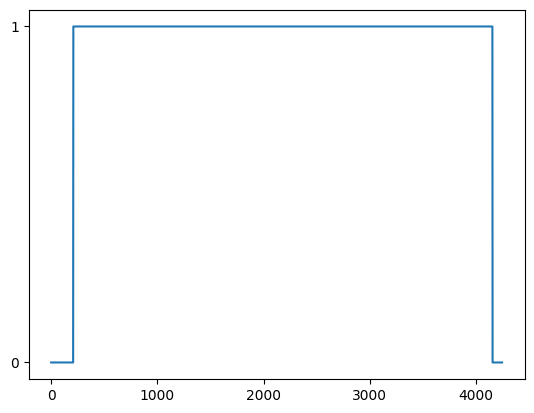

In [13]:
plt.plot(ar_df['sync'])

In [14]:
ar_df['sync'][0]

'0'

In [15]:
ar_df = ar_df.with_columns(
    pl.col("sync").cast(pl.Int8).cast(pl.Boolean)
)

In [16]:
start_pulse = ar_df["sync"].arg_true().head(1).item()
offset = (~ar_df["sync"].slice(start_pulse)).arg_true().head(1).item()

end_pulse = start_pulse + offset

print(f"Start pulse: {start_pulse}, End pulse: {end_pulse}")
ar_df = ar_df[start_pulse:end_pulse]
ar_corners = ar_results['corners'][start_pulse:end_pulse]
ids = ar_results['ids'][start_pulse:end_pulse]

_time_diff = mocap_df["time"][0] - ar_df["time"][0]

ar_df = ar_df.with_columns([(pl.col("time") + _time_diff).alias("time")])

Start pulse: 208, End pulse: 4154


In [17]:
mocap_df["time"][0]

datetime.datetime(2026, 2, 12, 17, 28, 10, 408000)

In [18]:
ar_df["time"][0]

datetime.datetime(2026, 2, 12, 17, 28, 10, 408000)

In [19]:
_time_diff

datetime.timedelta(microseconds=49476)

In [20]:
mocap_mean = {"x": [], "y": [], "z": []}
mocap_mean["x"] = mocap_df[[tr["x"], tl["x"], br["x"], bl["x"]]].to_numpy().mean(axis=1)
mocap_mean["y"] = mocap_df[[tr["y"], tl["y"], br["y"], bl["y"]]].to_numpy().mean(axis=1)
mocap_mean["z"] = mocap_df[[tr["z"], tl["z"], br["z"], bl["z"]]].to_numpy().mean(axis=1)

mocap_qt_0 = mocap_df[["rb_ang_x", "rb_ang_y", "rb_ang_z", "rb_ang_w"]][0].to_numpy()

mocap_rotation = R.from_quat(mocap_qt_0).as_matrix()

mocap_mean = pl.from_dict(mocap_mean)

mt_dict = {"x": [], "y": [], "z": []}
rmat_m = mocap_rotation[0]

for i in range(len(mocap_df["time"])):
    tvec_ar = rmat_m.T @ (
        mocap_mean[["x", "y", "z"]][i].to_numpy().reshape(3, 1)
        - mocap_mean[["x", "y", "z"]][0].to_numpy().reshape(3, 1)
    )
    tvec_ar = tvec_ar.T[0]
    mt_dict["x"].append(tvec_ar[0])
    mt_dict["y"].append(tvec_ar[1])
    mt_dict["z"].append(tvec_ar[2])

mt_dict["time"] = mocap_df["time"]

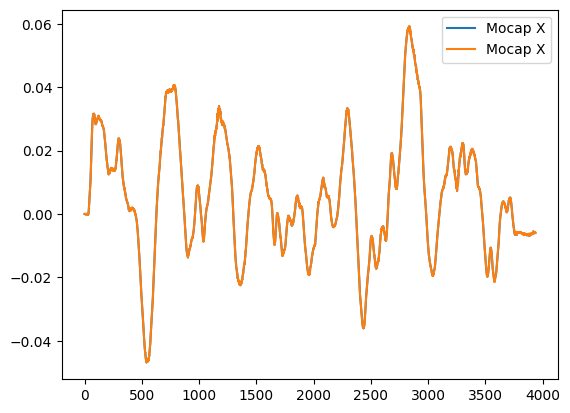

In [21]:
plt.plot(mt_dict["x"], label='Mocap X')
plt.plot(mt_dict["x"], label='Mocap X')
plt.legend()
plt.show()

In [22]:
mc_angle_arr = mocap_df[["rb_ang_x", "rb_ang_y", "rb_ang_z", "rb_ang_w"]].to_numpy()
mocap_angle = []
mc_ang_x = []
mc_ang_y = []
mc_ang_z = []
for _a in mc_angle_arr:
    try:
        _ax, _ay, _az = R.from_matrix(
            mocap_rotation[0].T @ R.from_quat(_a).as_matrix()
        ).as_euler("xyz", degrees=True)
        mc_ang_x.append(_ax)
        mc_ang_y.append(_ay)
        mc_ang_z.append(_az)
    except:
        _ax, _ay, _az = R.from_matrix(mocap_rotation[0].T @ np.eye(3)).as_euler(
            "xyz", degrees=True
        )
        mc_ang_x.append(_ax)
        mc_ang_y.append(_ay)
        mc_ang_z.append(_az)

## Interoplating

In [23]:
mocap = pl.from_dict(mt_dict)

x1 = interp1d(mocap["time"].dt.epoch(), mocap["x"], fill_value="extrapolate")
y1 = interp1d(mocap["time"].dt.epoch(), mocap["y"], fill_value="extrapolate")
z1 = interp1d(mocap["time"].dt.epoch(), mocap["z"], fill_value="extrapolate")

ax = interp1d(mocap["time"].dt.epoch(), mc_ang_x, fill_value="extrapolate")
ay = interp1d(mocap["time"].dt.epoch(), mc_ang_y, fill_value="extrapolate")
az = interp1d(mocap["time"].dt.epoch(), mc_ang_z, fill_value="extrapolate")

mocap_ip = {"time": ar_df["time"]}
mocap_ip["x"] = x1(ar_df["time"].dt.epoch())
mocap_ip["y"] = y1(ar_df["time"].dt.epoch())
mocap_ip["z"] = z1(ar_df["time"].dt.epoch())
mocap_ip["rx"] = ax(ar_df["time"].dt.epoch())
mocap_ip["ry"] = ay(ar_df["time"].dt.epoch())
mocap_ip["rz"] = az(ar_df["time"].dt.epoch())

mocap_ip = pl.from_dict(mocap_ip)

In [24]:
default_ids = [12, 14, 20]

In [25]:
len(my_dict["mat"])

200

### Evaluating a section to see everything is right

In [ ]:
all_corners_list = []
corner_counts = []
print("Filtering corners for ID 12...")
for _corner, _id in zip(ar_corners, ids):
    try:
        id_index = _id.reshape(-1).tolist().index(12)
        all_corners_list.append(np.array(_corner[id_index]).reshape(-1, 2))
        corner_counts.append(len(np.array(_corner[id_index]).reshape(-1, 2)))
    except ValueError:
        corner_counts.append(0)
all_corners_concat = np.vstack(all_corners_list).reshape(-1, 1, 2)

_i = 5 
fish_mat = my_dict["mat"][_i]
fish_dist = my_dict["dist"][_i]
_new_cam = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
    fish_mat, fish_dist, (1280, 800), np.eye(3), balance=1
)

# Batch undistort
undist_all = cv2.fisheye.undistortPoints(
    all_corners_concat, fish_mat, fish_dist, None, _new_cam
)

# Split back into individual corner sets
undist_corners = []
idx = 0
for count in corner_counts:
    if count > 0:
        undist_corners.append(undist_all[idx:idx+count])
        idx += count
    else:
        undist_corners.append(None)

# Pre-allocate arrays
num_markers = len(undist_corners)
rvecs = np.full((num_markers, 3), np.nan)
tvecs = np.full((num_markers, 3), np.nan)

for idx, _c in enumerate(undist_corners):
    if _c is not None:  # Already filtered for ID 12
        num_detected_markers = _c.shape[0] // 4
        reshaped_corners = [
            _c[j * 4:(j + 1) * 4].reshape(4, 1, 2)
            for j in range(num_detected_markers)
        ]
        
        rotation_vectors, translation_vectors = estimate_pose_single_markers(
            corners=reshaped_corners,
            marker_size=0.05,
            camera_matrix=_new_cam,
            distortion_coefficients=fish_dist,
        )
        
        if rotation_vectors is not None and len(rotation_vectors) > 0:
            rvecs[idx] = rotation_vectors[0][0]
            tvecs[idx] = translation_vectors[0][0]

# Find first valid (non-NaN) marker to use as reference
valid_idx = None
for idx in range(len(rvecs)):
    if not np.isnan(rvecs[idx]).any():
        valid_idx = idx
        break

# Vectorize transformation calculations using first valid marker as reference
rmat = cv2.Rodrigues(rvecs[valid_idx])[0]
rmat_T = rmat.T

# Vectorized translation transformation
tvec_diff = tvecs - tvecs[valid_idx]
tvec_transformed = (rmat_T @ tvec_diff.T).T

Filtering corners for ID 12...


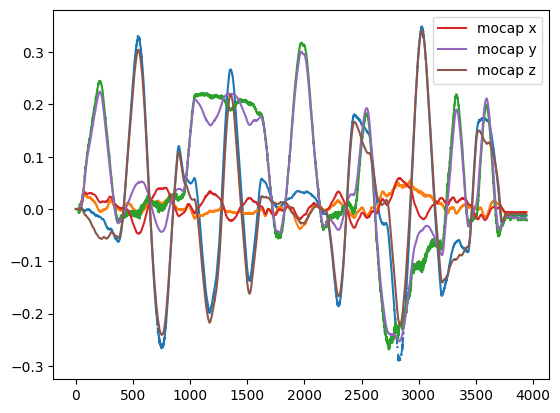

In [70]:
plt.plot(tvec_transformed)
plt.plot(mt_dict["x"], label="mocap x")
plt.plot(mt_dict["y"], label="mocap y")
plt.plot(mt_dict["z"], label="mocap z")
plt.legend()
plt.show()


In [26]:
from joblib import Parallel, delayed
import numpy as np
import cv2
from scipy.spatial.transform import Rotation as R
from tqdm import tqdm

def process_single_iteration(i, fish_mat, fish_dist, all_corners_concat, corner_counts, mocap_x, mocap_y, mocap_z):
    """Process a single iteration of the calibration loop"""
    
    _new_cam = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
        fish_mat, fish_dist, (1280, 800), np.eye(3), balance=1
    )
    
    # Batch undistort
    undist_all = cv2.fisheye.undistortPoints(
        all_corners_concat, fish_mat, fish_dist, None, _new_cam
    )
    
    # Split back into individual corner sets
    undist_corners = []
    idx = 0
    for count in corner_counts:
        if count > 0:
            undist_corners.append(undist_all[idx:idx+count])
            idx += count
        else:
            undist_corners.append(None)
    
    # Pre-allocate arrays
    num_markers = len(undist_corners)
    rvecs = np.full((num_markers, 3), np.nan)
    tvecs = np.full((num_markers, 3), np.nan)
    
    for idx, _c in enumerate(undist_corners):
        if _c is not None:  # Already filtered for ID 12
            num_detected_markers = _c.shape[0] // 4
            reshaped_corners = [
                _c[j * 4:(j + 1) * 4].reshape(4, 1, 2)
                for j in range(num_detected_markers)
            ]
            
            rotation_vectors, translation_vectors = estimate_pose_single_markers(
                corners=reshaped_corners,
                marker_size=0.05,
                camera_matrix=_new_cam,
                distortion_coefficients=fish_dist,
            )
            
            if rotation_vectors is not None and len(rotation_vectors) > 0:
                rvecs[idx] = rotation_vectors[0][0]
                tvecs[idx] = translation_vectors[0][0]
    
    # Find first valid (non-NaN) marker to use as reference
    valid_idx = None
    for idx in range(len(rvecs)):
        if not np.isnan(rvecs[idx]).any():
            valid_idx = idx
            break
    
    # If no valid markers found, return NaN
    if valid_idx is None:
        return {
            'err_x': np.nan,
            'err_y': np.nan,
            'err_z': np.nan,
            'mean_err': np.nan,
            'idx': i
        }
    
    # Vectorize transformation calculations using first valid marker as reference
    rmat = cv2.Rodrigues(rvecs[valid_idx])[0]
    rmat_T = rmat.T
    
    # Vectorized translation transformation
    tvec_diff = tvecs - tvecs[valid_idx]
    tvec_transformed = (rmat_T @ tvec_diff.T).T
    
    # Vectorize error calculations
    _ex = np.nanmean(np.abs(tvec_transformed[:, 0] - mocap_x))
    _ey = np.nanmean(np.abs(tvec_transformed[:, 1] - mocap_y))
    _ez = np.nanmean(np.abs(tvec_transformed[:, 2] - mocap_z))
    _mean_err = np.nanmean([_ex, _ey, _ez])
    
    _max_x = np.nanmax(np.abs(tvec_transformed[:, 0] - mocap_x))
    _max_y = np.nanmax(np.abs(tvec_transformed[:, 1] - mocap_y))
    _max_z = np.nanmax(np.abs(tvec_transformed[:, 2] - mocap_z))
    
    return {
        'err_x': _max_x,
        'err_y': _max_y,
        'err_z': _max_z,
        'mean_err': _mean_err,
        'idx': i
    }


# ============================================================================
# MAIN EXECUTION
# ============================================================================

# Batch undistort - collect all valid corners first, ONLY for ID 12
all_corners_list = []
corner_counts = []
print("Filtering corners for ID 12...")
for _corner, _id in zip(ar_corners, ids):
    # Only process if corner exists AND ID is 12
    if (_corner is not None and len(_corner) > 0 and 
        _id is not None and len(_id) > 0 and np.array(_id)[0] == 12):
        all_corners_list.append(np.array(_corner).reshape(-1, 2))
        corner_counts.append(len(np.array(_corner).reshape(-1, 2)))
    else:
        corner_counts.append(0)

print(f"Found {sum(1 for c in corner_counts if c > 0)} valid corners with ID 12 out of {len(corner_counts)} total")

# Check if we have any valid corners
if not all_corners_list:
    raise ValueError("No valid corners found for ID 12! Check your filtering logic.")

# Concatenate all corners for batch processing
all_corners_concat = np.vstack(all_corners_list).reshape(-1, 1, 2)
print(f"Concatenated corners shape: {all_corners_concat.shape}")

# Pre-compute mocap arrays once
mocap_x = mocap_ip["x"].to_numpy()
mocap_y = mocap_ip["y"].to_numpy()
mocap_z = mocap_ip["z"].to_numpy()

# Parallel processing
n_jobs = 12  # Adjust based on your CPU cores (-1 for all cores)
print(f"Processing {len(my_dict['mat'])} iterations with {n_jobs} parallel jobs...")

results = Parallel(n_jobs=n_jobs, verbose=10)(
    delayed(process_single_iteration)(
        i, 
        my_dict["mat"][i], 
        my_dict["dist"][i],
        all_corners_concat,
        corner_counts,
        mocap_x,
        mocap_y,
        mocap_z
    )
    for i in range(len(my_dict["mat"]))
)

# Collect results into dictionary
error_dict = {
    "err_x": [r['err_x'] for r in results],
    "err_y": [r['err_y'] for r in results],
    "err_z": [r['err_z'] for r in results],
    "mean_err": [r['mean_err'] for r in results],
    "idx": [r['idx'] for r in results]
}

print("Processing complete!")
print(f"Valid results: {sum(1 for x in error_dict['mean_err'] if not np.isnan(x))}/{len(error_dict['mean_err'])}")
print(f"Mean error (excluding NaN): {np.nanmean(error_dict['mean_err']):.4f}")

Filtering corners for ID 12...
Found 22 valid corners with ID 12 out of 3946 total
Concatenated corners shape: (212, 1, 2)
Processing 200 iterations with 12 parallel jobs...


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:    0.3s
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Batch computation too fast (0.19099426670758352s.) Setting batch_size=2.
[Parallel(n_jobs=12)]: Done  37 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done  62 tasks      | elapsed:    0.5s
[Parallel(n_jobs=12)]: Batch computation too fast (0.08914303779602051s.) Setting batch_size=4.
[Parallel(n_jobs=12)]: Done  88 tasks      | elapsed:    0.6s
[Parallel(n_jobs=12)]: Batch computation too fast (0.16017889976501465s.) Setting batch_size=8.
[Parallel(n_jobs=12)]: Done 128 tasks      | elapsed:    0.7s


Processing complete!
Valid results: 200/200
Mean error (excluding NaN): 0.1965


[Parallel(n_jobs=12)]: Done 164 tasks      | elapsed:    0.7s
[Parallel(n_jobs=12)]: Done 198 out of 200 | elapsed:    0.8s remaining:    0.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.8s finished


In [27]:
error_dict['err_y']

[np.float64(0.3192158933404224),
 np.float64(0.33465490773420564),
 np.float64(0.31661377852828665),
 np.float64(0.3253120121699812),
 np.float64(0.3281175927772994),
 np.float64(0.32510381999524307),
 np.float64(0.33590068733282413),
 np.float64(0.3147825798995181),
 np.float64(0.3314996175488828),
 np.float64(0.31864940324386076),
 np.float64(0.3296485496651652),
 np.float64(0.33542057016849697),
 np.float64(0.3164127713248256),
 np.float64(0.31678918719017896),
 np.float64(0.3058209953980598),
 np.float64(0.3347703876336439),
 np.float64(0.31698782532719405),
 np.float64(0.29160732215531593),
 np.float64(0.3376445432797371),
 np.float64(0.33025745066160284),
 np.float64(0.3211238630420474),
 np.float64(0.3245034923036833),
 np.float64(0.30897924558487544),
 np.float64(0.3179451246485407),
 np.float64(0.321504699991965),
 np.float64(0.32283182164422286),
 np.float64(0.3334928790787355),
 np.float64(0.3195788485890681),
 np.float64(0.2961650347269268),
 np.float64(0.335461524632765),


In [28]:
len(ids), len(ar_corners)

(3946, 3946)

In [29]:
ids

[array([[20],
        [12],
        [14]], dtype=int32),
 array([[20],
        [12],
        [14]], dtype=int32),
 array([[20],
        [12],
        [14]], dtype=int32),
 array([[20],
        [12],
        [14]], dtype=int32),
 array([[20],
        [12],
        [14]], dtype=int32),
 array([[20],
        [12],
        [14]], dtype=int32),
 array([[20],
        [12],
        [14]], dtype=int32),
 array([[20],
        [12],
        [14]], dtype=int32),
 array([[20],
        [12],
        [14]], dtype=int32),
 array([[20],
        [12],
        [14]], dtype=int32),
 array([[20],
        [12],
        [14]], dtype=int32),
 array([[20],
        [12],
        [14]], dtype=int32),
 array([[20],
        [12],
        [14]], dtype=int32),
 array([[20],
        [12],
        [14]], dtype=int32),
 array([[20],
        [12],
        [14]], dtype=int32),
 array([[20],
        [12],
        [14]], dtype=int32),
 array([[20],
        [12],
        [14]], dtype=int32),
 array([[20],
        [12],
   

In [30]:
# plt.plot(np.array(t_dict["z"]), label='AR X')
# plt.plot(mocap_ip["z"], label='Mocap X')
# plt.legend()

In [31]:
backup_dict = error_dict.copy()

In [32]:
np.min(error_dict['err_x'])

np.float64(0.5591670116497992)

## estimation

In [33]:
with open(os.path.join(_webcam_calib_video), "rb") as _f:
    data = list(mp.Unpacker(_f, object_hook=mpn.decode))
img_size = data[0]
video_data = data[1:]

NameError: name '_webcam_calib_video' is not defined

In [ ]:
default_ids = [12]

In [ ]:
if not np.isnan(rvecs[0]).any():
    print('inside')

inside


In [ ]:
error_dict = {
    "error": [],
    "mtx": [],
    "dist_coeffs": [],
    "error_x": [],
    "error_z": [],
    "error_y": [],
    "mean_err": [],
    "max_x": [],
    "max_y": [],
    "max_z": [],
    "error_ax": [],
    "error_ay": [],
    "error_az": [],
    "mean_error_ang": [],
}

for data in results:
    error_dict["error"].append(data[0])
    error_dict["mtx"].append(data[4])
    error_dict["dist_coeffs"].append(data[5])
    error_dict["error_x"].append(data[1])
    error_dict["error_y"].append(data[2])
    error_dict["error_z"].append(data[3])
    error_dict["mean_err"].append(data[6])
    error_dict["max_x"].append(data[7])
    error_dict["max_y"].append(data[8])
    error_dict["max_z"].append(data[9])
    error_dict["error_ax"].append(data[10])
    error_dict["error_ay"].append(data[11])
    error_dict["error_az"].append(data[12])
    error_dict["mean_error_ang"].append(data[13])

## Check minimum graph

In [ ]:
key = "mean_err"

index = np.argmin(error_dict[key])

_fish_mat = my_dict['mat'][index]
_fish_dist = my_dict['dist'][index]

# _fish_mat = _fish_matrix
# _fish_dist = _fist_dist
# key = "mean_err"

# index = np.argmin(error_dict[key])

# _fish_mat = my_dict['mat'][index]
# _fish_dist = my_dict['dist'][index]
_new_cam = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
    _fish_mat, _fish_dist, (1200, 800), np.eye(3), balance=1
)

undist_corners = []
for _corner in corners:
    _uc = cv2.fisheye.undistortPoints(
        np.array(_corner).reshape(-1, 1, 2), _fish_mat, _fish_dist, None, _new_cam
    )
    undist_corners.append(_uc)

camera_matrix = _new_cam
dist_coeffs = _fish_dist

rvecs = []
tvecs = []
rotation_vectors = None
translation_vectors = None
for _c, _i in zip(undist_corners, ids):
    if (_i is not None and len(_i) > 0) and all(
        item in default_ids for item in np.array(_i)
    ):
        _c = np.array([_c.reshape(-1, 2)]).astype(np.float32)
        rotation_vectors, translation_vectors = estimate_pose_single_markers(
            corners=_c,
            marker_size=0.05,
            camera_matrix=camera_matrix,
            distortion_coefficients=dist_coeffs,
        )

        try:
            rvecs.append(rotation_vectors[0][0])
            tvecs.append(translation_vectors[0][0])
        except:
            rvecs.append(np.array([np.nan, np.nan, np.nan]))
            tvecs.append(np.array([np.nan, np.nan, np.nan]))
    else:
        rvecs.append(np.array([np.nan, np.nan, np.nan]))
        tvecs.append(np.array([np.nan, np.nan, np.nan]))

tvecs = np.array(tvecs)
rvecs = np.array(rvecs)
t_dict = {"x": [], "y": [], "z": []}
rmat = cv2.Rodrigues(rvecs[1])[0]
ang_dict = {"rx": [], "ry": [], "rz": []}
for i in range(len(tvecs)):
    tvec = rmat.T @ (tvecs[i].reshape(3, 1) - tvecs[1].reshape(3, 1))
    tvec = tvec.T[0]
    t_dict["x"].append(tvec[0])
    t_dict["y"].append(tvec[1])
    t_dict["z"].append(tvec[2])
    _ang = R.from_matrix(rmat.T @ R.from_rotvec(rvecs[i]).as_matrix()).as_euler(
        "XYZ", degrees=True
    )
    ang_dict["rx"].append(_ang[0])
    ang_dict["ry"].append(_ang[1])
    ang_dict["rz"].append(_ang[2])

ValueError: attempt to get argmin of an empty sequence

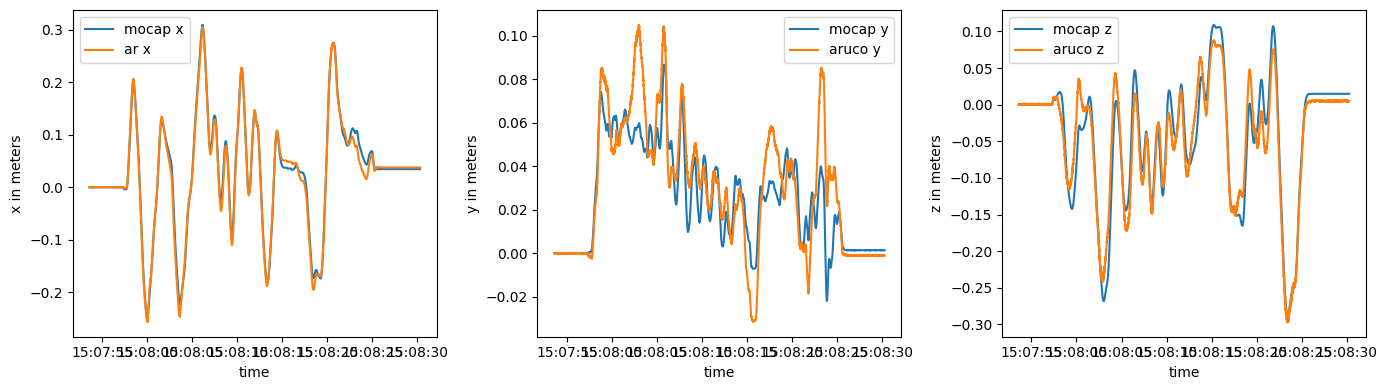

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(ar_df["time"], mocap_ip["x"], label="mocap x")
axes[0].plot(ar_df["time"], t_dict["x"], label="ar x")
axes[0].set_xlabel("time")
axes[0].set_ylabel("x in meters")
axes[0].legend()

axes[1].plot(ar_df["time"], mocap_ip["y"], label="mocap y")
axes[1].plot(ar_df["time"], t_dict["y"], label="aruco y")
axes[1].set_xlabel("time")
axes[1].set_ylabel("y in meters")
axes[1].legend()

axes[2].plot(ar_df["time"], mocap_ip["z"], label="mocap z")
axes[2].plot(ar_df["time"], np.array(t_dict["z"]), label="aruco z")
axes[2].set_xlabel("time")
axes[2].set_ylabel("z in meters")
axes[2].legend()
# axes[2].set_ylim([-0.01, 0.01])

plt.tight_layout()
plt.show()

In [ ]:
_cumulative_error = (
    np.array(error_dict["max_x"])
    + np.array(error_dict["max_y"])
    + np.array(error_dict["max_z"])
)
np.argmin(_cumulative_error)

2572

In [ ]:
mtx1 = error_dict["mtx"][index]
dist1 = error_dict["dist_coeffs"][index]

In [ ]:
error_dict["dist_coeffs"][index]

array([[-0.03554025, -0.31041969, -0.00555178, -0.00835112,  0.23764884]])

In [ ]:
import toml

data = toml.load(r"E:\CMC\pyprojects\programs_rpi\rpi_python\calib_test.toml")
data["calibration"]["camera_matrix"] = mtx1.tolist()
data["calibration"]["dist_coeffs"] = dist1.tolist()
data["camera"]["resolution"] = (1200, 480)
with open(
    r"E:\CMC\pyprojects\programs_rpi\rpi_python\calib_mono_faith3D.toml", "w"
) as f:
    toml.dump(data, f)

In [ ]:
key = "error"

index = np.argmin(error_dict[key])

index = 65
camera_matrix = error_dict["mtx"][index]
dist_coeffs = error_dict["dist_coeffs"][index]

rvecs = []
tvecs = []
for _c, _i in zip(corners, ids):
    if (_i is not None and len(_i) > 0) and all(
        item in default_ids for item in np.array(_i)
    ):
        rotation_vectors, translation_vectors = estimate_pose_single_markers(
            corners=_c,
            marker_size=0.05,
            camera_matrix=camera_matrix,
            distortion_coefficients=dist_coeffs,
        )
        rvecs.append(rotation_vectors[0][0])
        tvecs.append(translation_vectors[0][0])

    else:
        rvecs.append(np.array([np.nan, np.nan, np.nan]))
        tvecs.append(np.array([np.nan, np.nan, np.nan]))

tvecs = np.array(tvecs)
rvecs = np.array(rvecs)

t_dict = {"x": [], "y": [], "z": []}
rmat = cv2.Rodrigues(rvecs[1])[0]
ang_dict = {"rx": [], "ry": [], "rz": []}
for i in range(len(tvecs)):
    tvec = rmat.T @ (tvecs[i].reshape(3, 1) - tvecs[1].reshape(3, 1))
    tvec = tvec.T[0]
    t_dict["x"].append(tvec[0])
    t_dict["y"].append(tvec[1])
    t_dict["z"].append(tvec[2])
    _ang = R.from_matrix(rmat.T @ R.from_rotvec(rvecs[i]).as_matrix()).as_euler(
        "XYZ", degrees=True
    )
    ang_dict["rx"].append(_ang[0])
    ang_dict["ry"].append(_ang[1])
    ang_dict["rz"].append(_ang[2])

ValueError: attempt to get argmin of an empty sequence

In [ ]:
index

2566

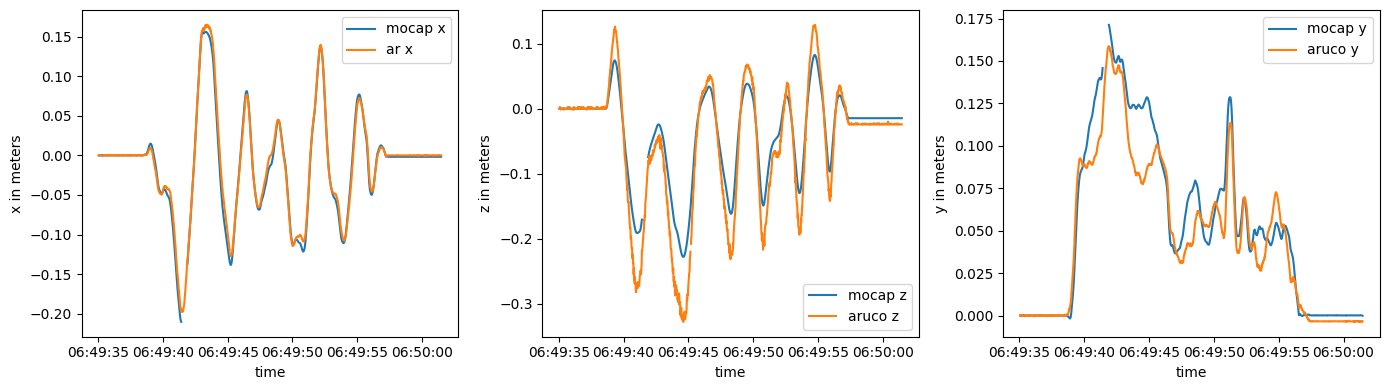

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(ar_df["time"], mocap_ip["x"], label="mocap x")
axes[0].plot(ar_df["time"], t_dict["x"], label="ar x")
axes[0].set_xlabel("time")
axes[0].set_ylabel("x in meters")
axes[0].legend()

axes[1].plot(ar_df["time"], mocap_ip["z"], label="mocap z")
axes[1].plot(ar_df["time"], np.array(t_dict["z"]), label="aruco z")
axes[1].set_xlabel("time")
axes[1].set_ylabel("z in meters")
axes[1].legend()

axes[2].plot(ar_df["time"], mocap_ip["y"], label="mocap y")
axes[2].plot(ar_df["time"], t_dict["y"], label="aruco y")
axes[2].set_xlabel("time")
axes[2].set_ylabel("y in meters")
axes[2].legend()
# axes[2].set_ylim([-0.01, 0.01])

plt.tight_layout()
plt.show()